## Introduction

The purpose of this notebook is to explore the outputs that we acheive from Xarray, CDO, and GDAL.

Usually a combination of these tools work nicely; however, a comparison of these tools can give you a picture of when to use what. 

**1- Xarray based outputs**

**2- CDO based outputs**

**3- GDAL based outputs**

Benchmarking of the methods on a small subset of data to see which one performs best. 


In [1]:

import geopandas as gpd
import xarray as xr
import numpy as np
import rioxarray as rio
import pandas as pd
import glob
import os
import re
import time
from datetime import datetime
import scipy
from tqdm import tqdm
from dask import delayed, compute
from dask.diagnostics import ProgressBar
from dask.distributed import Client, LocalCluster

import logging

import xesmf as xe

from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import lexcube 
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual

## Xarray Based OUTPUT

In [5]:
## trying python to preporcess
data_folder = Path("/home/kzakir/dvcube/test/test_data/2010")
file_list = sorted(glob.glob(str(data_folder / "*.nc")))
file_list

['/home/kzakir/dvcube/test/test_data/2010/h141_2010010100_R01.nc',
 '/home/kzakir/dvcube/test/test_data/2010/h141_2010010200_R01.nc',
 '/home/kzakir/dvcube/test/test_data/2010/h141_2010010300_R01.nc',
 '/home/kzakir/dvcube/test/test_data/2010/h141_2010010400_R01.nc',
 '/home/kzakir/dvcube/test/test_data/2010/h141_2010010500_R01.nc',
 '/home/kzakir/dvcube/test/test_data/2010/test.nc']

In [4]:
# use weights and regridder to resample
ds = xr.open_dataset(file_list[0])
ds
# change long to 180 format
ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby('lon')
ds

<xarray.Dataset> Size: 104MB
Dimensions:  (time: 1, lat: 1801, lon: 3600)
Coordinates:
  * time     (time) datetime64[ns] 8B 2010-01-01
  * lat      (lat) float64 14kB 90.0 89.9 89.8 89.7 ... -89.7 -89.8 -89.9 -90.0
  * lon      (lon) float64 29kB -180.0 -179.9 -179.8 ... 179.7 179.8 179.9
Data variables:
    var40    (time, lat, lon) float32 26MB ...
    var41    (time, lat, lon) float32 26MB ...
    var42    (time, lat, lon) float32 26MB ...
    var43    (time, lat, lon) float32 26MB ...
Attributes:
    CDI:          Climate Data Interface version 1.9.8 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Sun Jul 26 12:04:00 2020: cdo -f nc4c -z zip_6 copy h141_20...
    institution:  European Centre for Medium-Range Weather Forecasts
    CDO:          Climate Data Operators version 1.9.8 (https://mpimet.mpg.de...

In [7]:
ds_test = xr.open_dataset(file_list[-1])
ds_test

<xarray.Dataset> Size: 26MB
Dimensions:  (time: 1, lat: 1801, lon: 3600)
Coordinates:
  * time     (time) datetime64[ns] 8B 2010-01-01
  * lat      (lat) float64 14kB -90.0 -89.9 -89.8 -89.7 ... 89.7 89.8 89.9 90.0
  * lon      (lon) float64 29kB 0.0 0.1 0.2 0.3 0.4 ... 359.6 359.7 359.8 359.9
Data variables:
    var40    (time, lat, lon) float32 26MB ...
Attributes:
    CDI:          Climate Data Interface version 1.9.8 (https://mpimet.mpg.de...
    CDO:          Climate Data Operators version 1.9.8 (https://mpimet.mpg.de...
    Conventions:  CF-1.5
    history:      Wed Jan 28 10:24:03 2026: GDAL CreateCopy( test.nc, ... )\n...
    institution:  European Centre for Medium-Range Weather Forecasts
    GDAL:         GDAL 3.4.1, released 2021/12/27

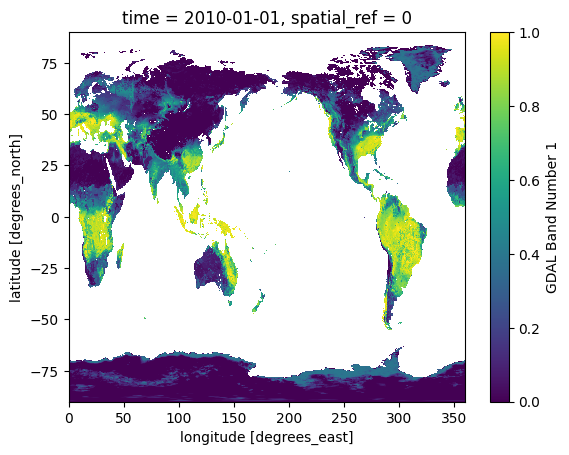

In [17]:
# check crs
assigned = ds_test.rio.write_crs("EPSG:4326", inplace=True)
assigned
assigned['var40'].isel(time=0).plot()

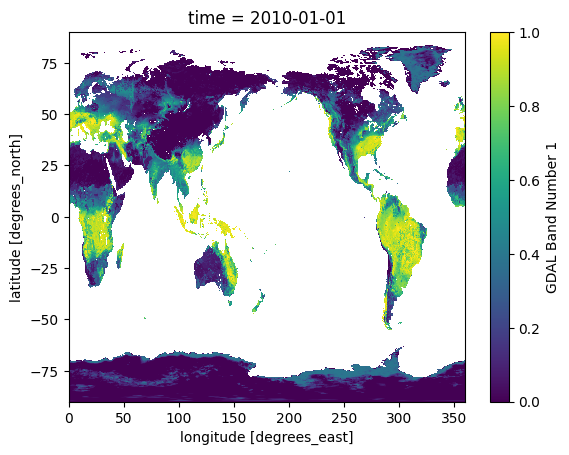

In [9]:
ds_test['var40'].isel(time=0).plot()

In [20]:
# test value in a point
print(ds_test['var40'].sel(lat=10, lon=10, method='nearest').values)
print(assigned['var40'].sel(lat=10, lon=10, method='nearest').values)

[0.09972095]
[0.09972095]


In [21]:
try_1 = xr.open_dataset('/data/dv-data/preprocessed/daily_evpt/2010/01/01/daily_evpt_20100101.nc')
try_1
print(try_1.rio.crs)

None


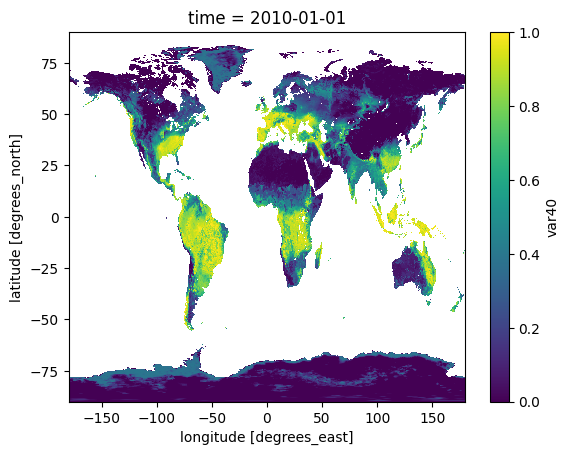

In [57]:
ds['var40'].isel(time=0).plot()


## CDO

In [21]:
# compare one file from each folder
before = "/home/kzakir/dvcube/test/test_data/2010/h141_2010010100_R01.nc"
after = "/home/kzakir/dvcube/test/outputs/cdo_output/2010/01/h141_2010010100_R01.nc_processed.nc"
ds1 = xr.open_dataset(before)
ds2 = xr.open_dataset(after)
ds1

<xarray.Dataset> Size: 104MB
Dimensions:  (time: 1, lat: 1801, lon: 3600)
Coordinates:
  * time     (time) datetime64[ns] 8B 2010-01-01
  * lat      (lat) float64 14kB 90.0 89.9 89.8 89.7 ... -89.7 -89.8 -89.9 -90.0
  * lon      (lon) float64 29kB 0.0 0.1 0.2 0.3 0.4 ... 359.6 359.7 359.8 359.9
Data variables:
    var40    (time, lat, lon) float32 26MB ...
    var41    (time, lat, lon) float32 26MB ...
    var42    (time, lat, lon) float32 26MB ...
    var43    (time, lat, lon) float32 26MB ...
Attributes:
    CDI:          Climate Data Interface version 1.9.8 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Sun Jul 26 12:04:00 2020: cdo -f nc4c -z zip_6 copy h141_20...
    institution:  European Centre for Medium-Range Weather Forecasts
    CDO:          Climate Data Operators version 1.9.8 (https://mpimet.mpg.de...

In [5]:
ds2

<xarray.Dataset> Size: 933kB
Dimensions:  (time: 1, lat: 100, lon: 580)
Coordinates:
  * time     (time) datetime64[ns] 8B 2010-01-01
  * lat      (lat) float64 800B 10.05 10.15 10.25 10.35 ... 19.75 19.85 19.95
  * lon      (lon) float64 5kB -17.95 -17.85 -17.75 -17.65 ... 39.75 39.85 39.95
Data variables:
    var40    (time, lat, lon) float32 232kB ...
    var41    (time, lat, lon) float32 232kB ...
    var42    (time, lat, lon) float32 232kB ...
    var43    (time, lat, lon) float32 232kB ...
Attributes:
    CDI:          Climate Data Interface version 2.0.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Tue Jan 27 13:00:53 2026: cdo -L -f nc4 -O -sellonlatbox,-1...
    CDO:          Climate Data Operators version 2.0.4 (https://mpimet.mpg.de...

In [25]:
# compare values at one grid point with linear interpolation

print(ds1['var40'].isel(time=0).sel(lat=15.0, lon=10.0).values)
print(ds2['var40'].isel(time=0).sel(lat=14.95, lon=9.95, method='nearest').values)

0.06724477
0.06733355


In [24]:
lats = np.random.uniform(10.05, 19.95, 100)
lons = np.random.uniform(-17.95, 39.95, 100)

lons_ds1 = np.where(lons < 0, lons + 360, lons)

diffs = []
for lat, lon, lon_ds1 in zip(lats, lons, lons_ds1):
 
    val1 = ds1['var40'].isel(time=0).sel(lat=lat, lon=lon_ds1, method='nearest').values
    val2 = ds2['var40'].isel(time=0).sel(lat=lat, lon=lon, method='nearest').values
    
    if not np.isnan(val1) and not np.isnan(val2):
        diffs.append(val2 - val1)

if diffs:
    print(f"Valid comparisons: {len(diffs)}/100")
    print("Mean difference:", np.mean(diffs))
    print("Std difference:", np.std(diffs))
    print("Min difference:", np.min(diffs))
    print("Max difference:", np.max(diffs))
else:
    print("No valid comparisons found!")

Valid comparisons: 93/100
Mean difference: 0.00212705
Std difference: 0.017402656
Min difference: -0.08179018
Max difference: 0.08489415


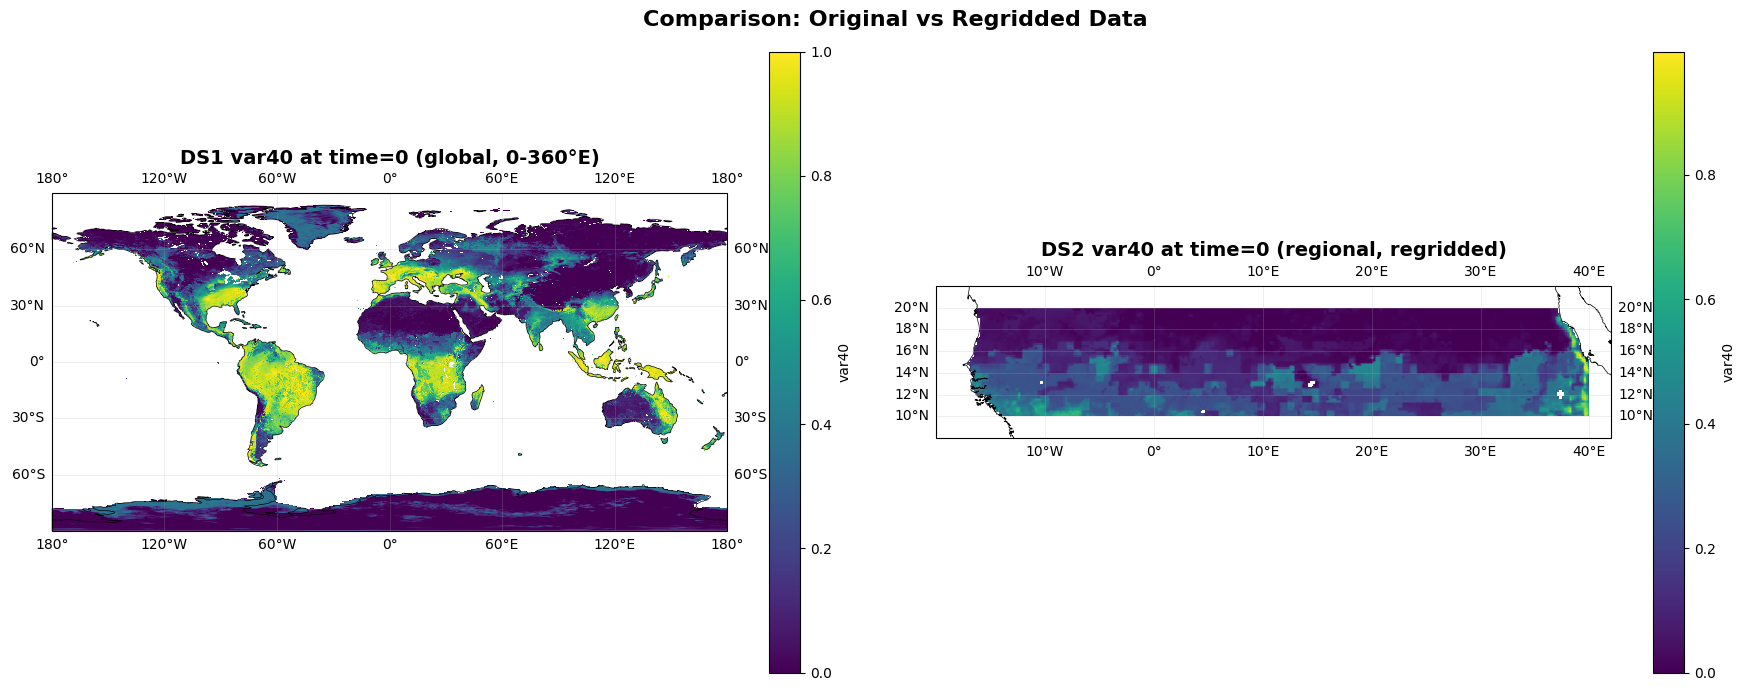

✓ Plots created successfully!
DS1 shape: (1, 1801, 3600)
DS2 shape: (1, 100, 580)


In [26]:
# Simple side-by-side comparison of DS1 and DS2
# Plot DS1 (global) and DS2 (regional) with their var40

fig, axes = plt.subplots(1, 2, figsize=(18, 7), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot DS1 - entire globe
ds1['var40'].isel(time=0).plot(ax=axes[0], transform=ccrs.PlateCarree(), 
                               cmap='viridis', cbar_kwargs={'label': 'var40'})
axes[0].add_feature(cfeature.COASTLINE, linewidth=0.5)
axes[0].set_global()
axes[0].set_title('DS1 var40 at time=0 (global, 0-360°E)', fontsize=14, fontweight='bold')
axes[0].gridlines(draw_labels=True, alpha=0.3, linewidth=0.5)

# Plot DS2 - regional (already at DS2's extent)
ds2['var40'].isel(time=0).plot(ax=axes[1], transform=ccrs.PlateCarree(),
                               cmap='viridis', cbar_kwargs={'label': 'var40'})
axes[1].add_feature(cfeature.COASTLINE, linewidth=0.5)
axes[1].set_xlim([-20, 42])
axes[1].set_ylim([8, 22])
axes[1].set_title('DS2 var40 at time=0 (regional, regridded)', fontsize=14, fontweight='bold')
axes[1].gridlines(draw_labels=True, alpha=0.3, linewidth=0.5)

plt.suptitle('Comparison: Original vs Regridded Data', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("✓ Plots created successfully!")
print(f"DS1 shape: {ds1['var40'].shape}")
print(f"DS2 shape: {ds2['var40'].shape}")

In [28]:
values = ds2["var40"].values
print(values.shape)
print(values)
print("min:", np.nanmin(values))
print("max:", np.nanmax(values))
print("mean:", np.nanmean(values))
print("std:", np.nanstd(values))
print ("Nan count:", np.sum(np.isnan(values)))

values_1 = ds1["var40"].values
print(values_1.shape)
print(values_1)
print("min:", np.nanmin(values_1))
print("max:", np.nanmax(values_1))
print("mean:", np.nanmean(values_1))
print("std:", np.nanstd(values_1))
print ("Nan count:", np.sum(np.isnan(values_1)))

(1, 100, 580)
[[[       nan        nan        nan ... 0.8214908  0.77489614 0.5577138 ]
  [       nan        nan        nan ... 0.8669773  0.8323691  0.6604638 ]
  [       nan        nan        nan ... 0.8976873  0.8393096  0.705011  ]
  ...
  [       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]]]
min: 0.0
max: 0.99766064
mean: 0.15193844
std: 0.14972018
Nan count: 2699
(1, 1801, 3600)
[[[       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]
  ...
  [0.06740427 0.06717682 0.06694925 ... 0.06826234 0.06797636 0.06769025]
  [0.06740427 0.06722116 0.06703794 ... 0.06809509 0.06786478 0.06763458]
  [0.         0.         0.         ... 0.         0.         0.    

In [11]:
# check one file
sample_file = all_files[0]
print(f"Opening sample file: {sample_file}")
ds = xr.open_dataset(sample_file)
ds

Opening sample file: /home/kzakir/dvcube/test/outputs/2010/01/var40/h141_2010010100_R01_var40.nc
Opening sample file: /home/kzakir/dvcube/test/outputs/2010/01/var40/h141_2010010100_R01_var40.nc


<xarray.Dataset> Size: 237kB
Dimensions:  (lat: 100, lon: 580)
Coordinates:
  * lat      (lat) float64 800B 10.05 10.15 10.25 10.35 ... 19.75 19.85 19.95
  * lon      (lon) float64 5kB -17.95 -17.85 -17.75 -17.65 ... 39.75 39.85 39.95
Data variables:
    Band1    (lat, lon) float32 232kB ...
    crs      |S1 1B ...
Attributes:
    Conventions:  CF-1.5
    GDAL:         GDAL 3.4.1, released 2021/12/27
    history:      Mon Jan 26 14:06:54 2026: GDAL Create( /tmp/tmp.Tm8CMO8KQ6/...

<xarray.Dataset> Size: 237kB
Dimensions:  (lat: 100, lon: 580)
Coordinates:
  * lat      (lat) float64 800B 10.05 10.15 10.25 10.35 ... 19.75 19.85 19.95
  * lon      (lon) float64 5kB -17.95 -17.85 -17.75 -17.65 ... 39.75 39.85 39.95
Data variables:
    Band1    (lat, lon) float32 232kB ...
    crs      |S1 1B ...
Attributes:
    Conventions:  CF-1.5
    GDAL:         GDAL 3.4.1, released 2021/12/27
    history:      Mon Jan 26 14:06:54 2026: GDAL Create( /tmp/tmp.Tm8CMO8KQ6/...

In [10]:
# help me plot
ds['Band1'].plot()


SyntaxError: invalid syntax (1138984120.py, line 19)

## LExcube

In [11]:
path = '/data/dv-data/preprocessed/evpt_combined_2010_2024.zarr'

print("Loading EVPT data from daily NetCDF files (10 time steps for testing)...")
print("="*60)

# Find daily EVPT files
daily_dir = '/data/dv-data/preprocessed/daily_evpt/'
all_files = sorted(glob.glob(os.path.join(daily_dir, '**/*.nc'), recursive=True))[:10]

if all_files:
    print(f"Loading {len(all_files)} daily files...")
    
    # Load and concatenate datasets
    datasets = [xr.open_dataset(f) for f in all_files]
    
    # Add time coordinate from filenames
    for ds, fpath in zip(datasets, all_files):
        # Extract date from filename (e.g., daily_evpt_20100101.nc)
        match = re.search(r'(\d{8})', os.path.basename(fpath))
        if match:
            date_str = match.group(1)
            date = pd.to_datetime(date_str, format='%Y%m%d')
            ds.coords['time'] = date
    
    # Concatenate along time dimension
    ds = xr.concat(datasets, dim='time')
    print(f"\n✓ Successfully loaded {len(ds.time)} time steps")
    print(ds)
    
    # Select subset for testing
    ds_test = ds.isel(time=slice(0, 10)) if len(ds.time) > 10 else ds
    da = ds_test['Band1']
    print(f"\nSelected data shape: {da.shape}")
    da
else:
    print("✗ No daily files found")

Loading EVPT data from daily NetCDF files (10 time steps for testing)...
Loading 10 daily files...
Loading 10 daily files...

✓ Successfully loaded 10 time steps
<xarray.Dataset> Size: 9MB
Dimensions:  (time: 10, lat: 200, lon: 1160)
Coordinates:
  * time     (time) datetime64[ns] 80B 2010-01-01 2010-01-02 ... 2010-01-10
  * lat      (lat) float64 2kB 10.03 10.07 10.12 10.18 ... 19.88 19.93 19.98
  * lon      (lon) float64 9kB -17.98 -17.93 -17.88 -17.82 ... 39.88 39.93 39.98
Data variables:
    Band1    (time, lat, lon) float32 9MB nan nan nan nan ... nan nan nan nan
    crs      (time) |S1 10B b'' b'' b'' b'' b'' b'' b'' b'' b'' b''
Attributes:
    Conventions:  CF-1.5
    GDAL:         GDAL 3.4.1, released 2021/12/27
    history:      Wed Oct 29 15:54:56 2025: GDAL Create( /data/dv-data/raw/da...

Selected data shape: (10, 200, 1160)

✓ Successfully loaded 10 time steps
<xarray.Dataset> Size: 9MB
Dimensions:  (time: 10, lat: 200, lon: 1160)
Coordinates:
  * time     (time) datetime6

In [12]:
# plot with lexcube
w = lexcube.Cube3DWidget(da, cmap='viridis', vmin=0, vmax=1)
print(w)
# enable ipyiwidgets

Xarray input object does not have chunks. You can re-open your data set with 'xr.open_dataset(..., chunks={})' to enable caching and accurate progress reporting - but may sometimes be slower for small data sets.
Cube3DWidget(api_metadata={'/api': {'status': 'ok', 'api_version': 5}, '/api/datasets': [{'id': 'default', 'shortName': "<class 'xarray.core.dataarray.DataArray'>"}], '/api/datasets/default': {'dims': {'time': 10, 'lat': 200, 'lon': 1160}, 'dims_ordered': ('time', 'lat', 'lon'), 'attrs': {}, 'coords': {'lat': {'dims': ('lat',), 'attrs': {'standard_name': 'latitude', 'long_name': 'latitude', 'units': 'degrees_north'}, 'data': [19.975, 19.925, 19.875, 19.825000000000003, 19.775, 19.725, 19.675, 19.625, 19.575000000000003, 19.525, 19.475, 19.425, 19.375, 19.325000000000003, 19.275, 19.225, 19.175, 19.125, 19.075000000000003, 19.025, 18.975, 18.925, 18.875, 18.825000000000003, 18.775, 18.725, 18.675, 18.625, 18.575000000000003, 18.525, 18.475, 18.425, 18.375, 18.325000000000003, 18

## Xarray + CDO

In [2]:
file = '../test/test_data/2010/h141_2010010100_R01.nc'

ds = xr.open_dataset(file)
ds

<xarray.Dataset> Size: 104MB
Dimensions:  (time: 1, lat: 1801, lon: 3600)
Coordinates:
  * time     (time) datetime64[ns] 8B 2010-01-01
  * lat      (lat) float64 14kB 90.0 89.9 89.8 89.7 ... -89.7 -89.8 -89.9 -90.0
  * lon      (lon) float64 29kB 0.0 0.1 0.2 0.3 0.4 ... 359.6 359.7 359.8 359.9
Data variables:
    var40    (time, lat, lon) float32 26MB ...
    var41    (time, lat, lon) float32 26MB ...
    var42    (time, lat, lon) float32 26MB ...
    var43    (time, lat, lon) float32 26MB ...
Attributes:
    CDI:          Climate Data Interface version 1.9.8 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Sun Jul 26 12:04:00 2020: cdo -f nc4c -z zip_6 copy h141_20...
    institution:  European Centre for Medium-Range Weather Forecasts
    CDO:          Climate Data Operators version 1.9.8 (https://mpimet.mpg.de...

In [4]:
output = xr.open_dataset('../test/test_data/2010/output.nc')
output.rio.write_crs("EPSG:4326", inplace=True)


<xarray.Dataset> Size: 104MB
Dimensions:      (time: 1, lat: 1801, lon: 3600)
Coordinates:
  * time         (time) datetime64[ns] 8B 2010-01-01
  * lat          (lat) float64 14kB 90.0 89.9 89.8 89.7 ... -89.8 -89.9 -90.0
  * lon          (lon) float64 29kB -180.0 -179.9 -179.8 ... 179.7 179.8 179.9
    spatial_ref  int64 8B 0
Data variables:
    var40        (time, lat, lon) float32 26MB ...
    var41        (time, lat, lon) float32 26MB ...
    var42        (time, lat, lon) float32 26MB ...
    var43        (time, lat, lon) float32 26MB ...
Attributes:
    CDI:          Climate Data Interface version 2.0.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Wed Jan 28 12:27:41 2026: cdo sellonlatbox,-180,180,-90,90 ...
    CDO:          Climate Data Operators version 2.0.4 (https://mpimet.mpg.de...

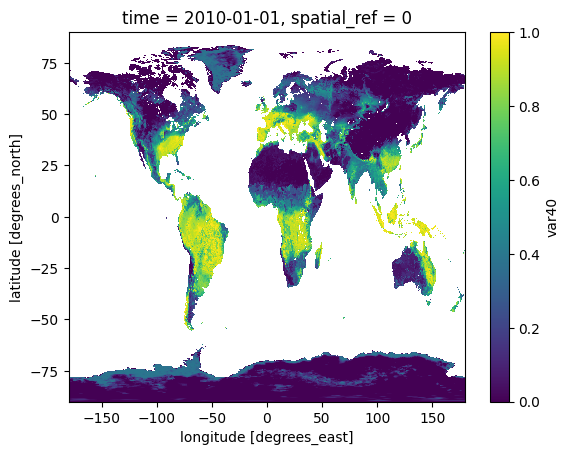

In [5]:
output['var40'].isel(time=0).plot()

In [31]:
# clip the values to the spatial units
# change gpkg to geojsojn

#gdf_file = gpd.read_file('../spatial_units_SciData.gpkg')
#gdf_file.to_file('spatial_units.geosjon', driver='GeoJson')


In [6]:
gdf_file_1 = gpd.read_file('../spatial_units.geosjon')
gdf_file_1

,id,name,zone_category,geometry
0,SEN.1.1.1-rural,Dakar-rural,rural,"MULTIPOLYGON (((-17.14005 14.57827, -17.14034 ..."
1,SEN.10.1.1-rural,Mbane-rural,rural,"MULTIPOLYGON (((-15.83737 16.21078, -15.87214 ..."
2,SEN.10.1.2-rural,Ndiaye Mberess-rural,rural,"MULTIPOLYGON (((-16.26705 16.0281, -16.24896 1..."
3,SEN.10.2.1-rural,Cas Cas-rural,rural,"MULTIPOLYGON (((-14.37828 16.01092, -14.44253 ..."
4,SEN.10.2.2-rural,Gamadji Sarre-rural,rural,"MULTIPOLYGON (((-15.03611 16.01448, -14.99439 ..."
...,...,...,...,...
146,city-048,Thiès,urban,"MULTIPOLYGON (((-17.00244 14.80395, -17.0009 1..."
147,city-049,Tivaouane,urban,"MULTIPOLYGON (((-16.8533 14.93582, -16.8485 14..."
148,city-050,Touba,urban,"MULTIPOLYGON (((-15.92335 14.7155, -15.95312 1..."
149,city-052,Vélingara,urban,"MULTIPOLYGON (((-14.1644 13.10737, -14.18021 1..."


In [7]:
# check the crs
output.rio.set_spatial_dims(x_dim='lon', y_dim= 'lat', inplace=True)


<xarray.Dataset> Size: 104MB
Dimensions:      (time: 1, lat: 1801, lon: 3600)
Coordinates:
  * time         (time) datetime64[ns] 8B 2010-01-01
  * lat          (lat) float64 14kB 90.0 89.9 89.8 89.7 ... -89.8 -89.9 -90.0
  * lon          (lon) float64 29kB -180.0 -179.9 -179.8 ... 179.7 179.8 179.9
    spatial_ref  int64 8B 0
Data variables:
    var40        (time, lat, lon) float32 26MB ...
    var41        (time, lat, lon) float32 26MB ...
    var42        (time, lat, lon) float32 26MB ...
    var43        (time, lat, lon) float32 26MB ...
Attributes:
    CDI:          Climate Data Interface version 2.0.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Wed Jan 28 12:27:41 2026: cdo sellonlatbox,-180,180,-90,90 ...
    CDO:          Climate Data Operators version 2.0.4 (https://mpimet.mpg.de...

In [10]:
# get the bounds of the gdf and then extreact the data
from shapely.geometry import mapping
clipped = output.rio.clip(gdf_file_1.geometry.apply(mapping), output.rio.crs, drop=False)
clipped

<xarray.Dataset> Size: 104MB
Dimensions:      (time: 1, lon: 3600, lat: 1801)
Coordinates:
  * time         (time) datetime64[ns] 8B 2010-01-01
  * lon          (lon) float64 29kB -180.0 -179.9 -179.8 ... 179.7 179.8 179.9
  * lat          (lat) float64 14kB 90.0 89.9 89.8 89.7 ... -89.8 -89.9 -90.0
    spatial_ref  int64 8B 0
Data variables:
    var40        (time, lat, lon) float32 26MB nan nan nan nan ... nan nan nan
    var41        (time, lat, lon) float32 26MB nan nan nan nan ... nan nan nan
    var42        (time, lat, lon) float32 26MB nan nan nan nan ... nan nan nan
    var43        (time, lat, lon) float32 26MB nan nan nan nan ... nan nan nan
Attributes:
    CDI:          Climate Data Interface version 2.0.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Wed Jan 28 12:27:41 2026: cdo sellonlatbox,-180,180,-90,90 ...
    CDO:          Climate Data Operators version 2.0.4 (https://mpimet.mpg.de...

In [11]:
clip_new = output.rio.clip_box(minx=-20, miny=12, maxx=-10, maxy=18)
clip_new

<xarray.Dataset> Size: 100kB
Dimensions:      (time: 1, lon: 101, lat: 61)
Coordinates:
  * time         (time) datetime64[ns] 8B 2010-01-01
  * lon          (lon) float64 808B -20.0 -19.9 -19.8 ... -10.2 -10.1 -10.0
  * lat          (lat) float64 488B 18.0 17.9 17.8 17.7 ... 12.3 12.2 12.1 12.0
    spatial_ref  int64 8B 0
Data variables:
    var40        (time, lat, lon) float32 25kB ...
    var41        (time, lat, lon) float32 25kB ...
    var42        (time, lat, lon) float32 25kB ...
    var43        (time, lat, lon) float32 25kB ...
Attributes:
    CDI:          Climate Data Interface version 2.0.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Wed Jan 28 12:27:41 2026: cdo sellonlatbox,-180,180,-90,90 ...
    CDO:          Climate Data Operators version 2.0.4 (https://mpimet.mpg.de...

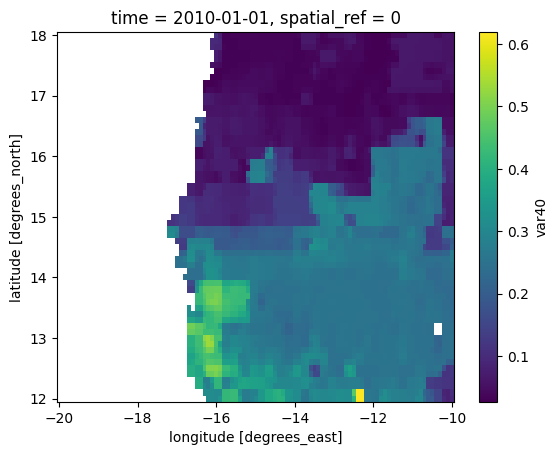

In [12]:
clip_new['var40'].isel(time=0).plot()

In [ ]:
# aggregate to spatial units (without clipping)
# Aggregate clip_new data to spatial units using zonal statistics - faster method without clipping

clip_new.rio.write_crs("EPSG:4326", inplace=True)
clip_new.rio.set_spatial_dims(x_dim='lon', y_dim='lat', inplace=True)

# Function to aggregate without clipping - uses spatial join
def aggregate_to_units_fast(ds, gdf, var_name='var40'):
    """
    Aggregate gridded data to spatial units (polygons) without clipping
    If no valid data in polygon, uses nearest point value
    """
    from shapely.geometry import Point
    from scipy.spatial import distance
    
    results = []
    
    # Create a point dataset from grid coordinates
    lats = ds.lat.values
    lons = ds.lon.values
    data_values = ds[var_name].isel(time=0).values
    
    # Create mesh grid of all points with their indices
    all_points = []
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            all_points.append({
                'lon': lon,
                'lat': lat,
                'i': i,
                'j': j,
                'val': data_values[i, j]
            })
    
    for idx, row in gdf.iterrows():
        geom = row.geometry
        unit_id = row.get('id', idx)
        
        try:
            # Find points within this polygon
            valid_values = []
            
            for pt_info in all_points:
                point = Point(pt_info['lon'], pt_info['lat'])
                if geom.contains(point):
                    val = pt_info['val']
                    if not np.isnan(val):
                        valid_values.append(val)
            
            # If no valid data, find nearest point with valid data to polygon centroid
            if not valid_values:
                centroid = np.array([geom.centroid.x, geom.centroid.y])
                
                # Find nearest point that has valid (non-NaN) data
                best_dist = float('inf')
                best_val = None
                
                for pt_info in all_points:
                    if not np.isnan(pt_info['val']):
                        pt_coords = np.array([pt_info['lon'], pt_info['lat']])
                        dist = distance.euclidean(centroid, pt_coords)
                        if dist < best_dist:
                            best_dist = dist
                            best_val = pt_info['val']
                
                if best_val is not None:
                    valid_values = [best_val]
                    print(f"Unit {unit_id}: Using nearest valid point value ({best_val:.4f})")
                else:
                    print(f"Warning: No valid data found anywhere for unit {unit_id}")
                    continue
            
            results.append({
                'unit_id': unit_id,
                'geometry': geom,
                'mean': float(np.mean(valid_values)),
                'std': float(np.std(valid_values)) if len(valid_values) > 1 else 0.0,
                'min': float(np.min(valid_values)),
                'max': float(np.max(valid_values)),
                'count': int(len(valid_values))
            })
                
        except Exception as e:
            print(f"Error processing unit {unit_id}: {e}")
            continue
    
    # Create GeoDataFrame with results
    result_gdf = gpd.GeoDataFrame(results, crs=gdf.crs)
    return result_gdf

aggregated = aggregate_to_units_fast(clip_new, gdf_file_1, var_name='var40')
print(f"Total units with data: {len(aggregated)}")


Aggregating data to spatial units (finding nearest valid point if no data)...
Unit city-001: Using nearest valid point value (0.2042)
Unit city-001: Using nearest valid point value (0.2042)
Unit city-032: Using nearest valid point value (0.1367)
Unit city-037: Using nearest valid point value (0.3096)
Unit city-032: Using nearest valid point value (0.1367)
Unit city-037: Using nearest valid point value (0.3096)
Unit city-039: Using nearest valid point value (0.0587)
Unit city-042: Using nearest valid point value (0.3096)
Unit city-039: Using nearest valid point value (0.0587)
Unit city-042: Using nearest valid point value (0.3096)
Unit city-049: Using nearest valid point value (0.1355)
Unit city-049: Using nearest valid point value (0.1355)
✓ Aggregation complete!
Aggregated 151 spatial units
Total units with data: 151
✓ Aggregation complete!
Aggregated 151 spatial units
Total units with data: 151


,unit_id,geometry,mean,std,min,max,count
0,SEN.1.1.1-rural,"MULTIPOLYGON (((-17.14005 14.57827, -17.14034 ...",0.301694,0.000000,0.301694,0.301694,1
1,SEN.10.1.1-rural,"MULTIPOLYGON (((-15.83737 16.21078, -15.87214 ...",0.060658,0.007522,0.051303,0.071561,24
2,SEN.10.1.2-rural,"MULTIPOLYGON (((-16.26705 16.0281, -16.24896 1...",0.072549,0.021959,0.054953,0.153251,27
3,SEN.10.2.1-rural,"MULTIPOLYGON (((-14.37828 16.01092, -14.44253 ...",0.067951,0.025084,0.040250,0.113021,21
4,SEN.10.2.2-rural,"MULTIPOLYGON (((-15.03611 16.01448, -14.99439 ...",0.083481,0.069991,0.040063,0.289847,40
...,...,...,...,...,...,...,...
146,city-048,"MULTIPOLYGON (((-17.00244 14.80395, -17.0009 1...",0.163148,0.000000,0.163148,0.163148,1
147,city-049,"MULTIPOLYGON (((-16.8533 14.93582, -16.8485 14...",0.135546,0.000000,0.135546,0.135546,1
148,city-050,"MULTIPOLYGON (((-15.92335 14.7155, -15.95312 1...",0.125718,0.049414,0.088032,0.195526,3
149,city-052,"MULTIPOLYGON (((-14.1644 13.10737, -14.18021 1...",0.216826,0.000000,0.216826,0.216826,1


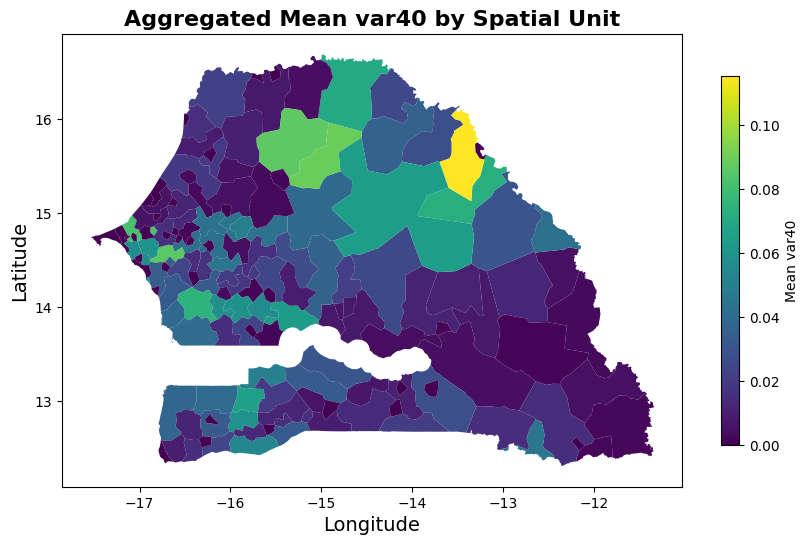

In [27]:
# plot it
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
aggregated.plot(column='std', ax=ax, legend=True, cmap='viridis',
                legend_kwds={'label': "Mean var40", 'shrink': 0.6})
ax.set_title('Aggregated Mean var40 by Spatial Unit', fontsize=16, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)
plt.show()

In [ ]:

all_variables = list(clip_new.data_vars)
all_aggregated = {}

for var_name in all_variables:
    print(f"\n--- Aggregating {var_name} ---")
    agg_result = aggregate_to_units_fast(clip_new, gdf_file_1, var_name=var_name)
    all_aggregated[var_name] = agg_result

# Combine all results into a single GeoDataFrame
# Start with first variable
combined_gdf = all_aggregated[all_variables[0]].copy()

# Rename columns to include variable name
for col in ['mean', 'std', 'min', 'max', 'count']:
    if col in combined_gdf.columns:
        combined_gdf = combined_gdf.rename(columns={col: f'{all_variables[0]}_{col}'})

# Add other variables
for var_name in all_variables[1:]:
    agg_gdf = all_aggregated[var_name]
    for col in ['mean', 'std', 'min', 'max', 'count']:
        if col in agg_gdf.columns:
            combined_gdf[f'{var_name}_{col}'] = agg_gdf[col].values

print(f"\n✓ Combined GeoDataFrame created with {len(combined_gdf)} spatial units")
print(f"Total columns: {len(combined_gdf.columns)}")
print(combined_gdf.head())


Processing all variables in the dataset...
Found variables: ['var40', 'var41', 'var42', 'var43']

--- Aggregating var40 ---
Unit city-001: Using nearest valid point value (0.2042)
Unit city-001: Using nearest valid point value (0.2042)
Unit city-032: Using nearest valid point value (0.1367)
Unit city-037: Using nearest valid point value (0.3096)
Unit city-032: Using nearest valid point value (0.1367)
Unit city-037: Using nearest valid point value (0.3096)
Unit city-039: Using nearest valid point value (0.0587)
Unit city-042: Using nearest valid point value (0.3096)
Unit city-039: Using nearest valid point value (0.0587)
Unit city-042: Using nearest valid point value (0.3096)
Unit city-049: Using nearest valid point value (0.1355)
Unit city-049: Using nearest valid point value (0.1355)

--- Aggregating var41 ---

--- Aggregating var41 ---
Unit city-001: Using nearest valid point value (0.1578)
Unit city-001: Using nearest valid point value (0.1578)
Unit city-032: Using nearest valid poi

In [21]:
# Save to GeoParquet (preserves geometry) and load for verification
geoparquet_path = '../aggregated_spatial_units.geoparquet'
combined_gdf.to_parquet(geoparquet_path)
print(f"\n✓ Saved to GeoParquet: {geoparquet_path}")

# Load it back for verification
gdf_loaded = gpd.read_parquet(geoparquet_path)
print(f"Loaded {len(gdf_loaded)} rows, {len(gdf_loaded.columns)} columns")
print(f"CRS: {gdf_loaded.crs}")
print(f"Geometry type: {gdf_loaded.geometry.type.unique()}")
print("\nFirst few rows:")
print(gdf_loaded.head())


✓ Saved to GeoParquet: ../aggregated_spatial_units.geoparquet
Loaded 151 rows, 22 columns
CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic l

Creating visualizations for all variables from GeoParquet...
Loaded GeoDataFrame: 151 spatial units, 22 columns
Found 4 variables: ['var40_mean', 'var41_mean', 'var42_mean', 'var43_mean']

✓ Saved visualization to: ../aggregated_spatial_units_visualization.png



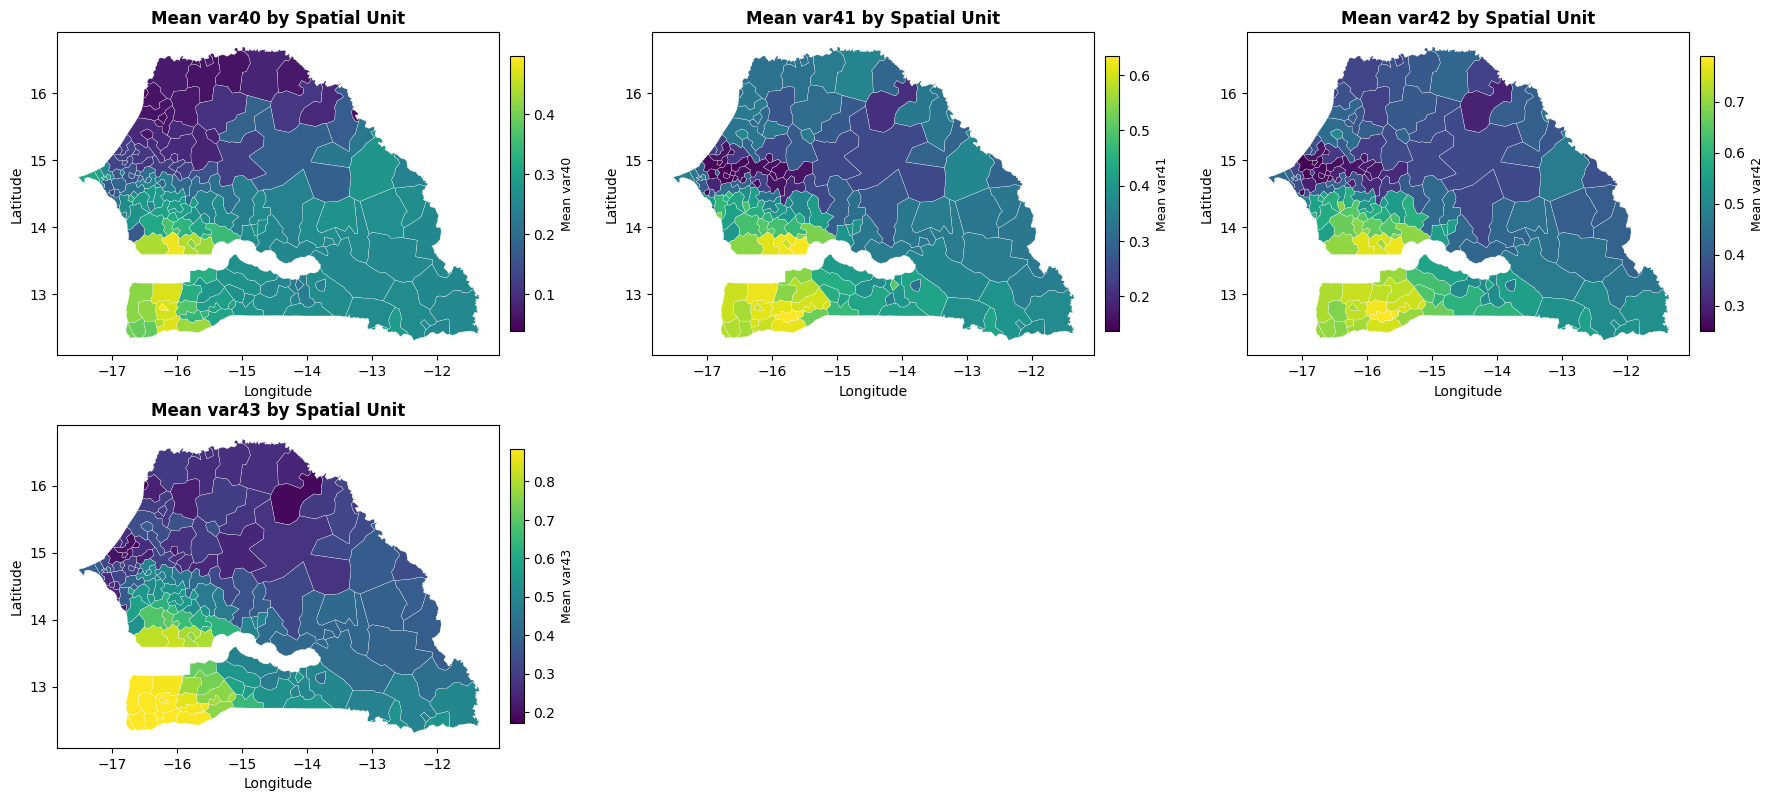

SUMMARY STATISTICS FOR ALL VARIABLES

var40:
  Mean: 0.233741
  Std:  0.107666
  Min:  0.038651
  Max:  0.495550
  Spatial units: 151

var41:
  Mean: 0.368537
  Std:  0.137066
  Min:  0.136892
  Max:  0.633962
  Spatial units: 151

var42:
  Mean: 0.493352
  Std:  0.152355
  Min:  0.250512
  Max:  0.788613
  Spatial units: 151

var43:
  Mean: 0.469317
  Std:  0.201527
  Min:  0.170005
  Max:  0.884716
  Spatial units: 151


In [ ]:
# Load GeoParquet file
geoparquet_path = '../aggregated_spatial_units.geoparquet'
gdf_plot = gpd.read_parquet(geoparquet_path)

print(f"Loaded GeoDataFrame: {len(gdf_plot)} spatial units, {len(gdf_plot.columns)} columns")

# Get all mean columns
mean_cols = [col for col in gdf_plot.columns if col.endswith('_mean')]
print(f"Found {len(mean_cols)} variables: {mean_cols}\n")

# Create subplots for each variable
n_vars = len(mean_cols)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten() if n_vars > 1 else [axes]

for idx, mean_col in enumerate(mean_cols):
    var_name = mean_col.replace('_mean', '')
    ax = axes[idx]
    
    # Plot with proper colorbar
    gdf_plot.plot(column=mean_col, ax=ax, cmap='viridis', 
                  edgecolor='white', linewidth=0.2)
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap='viridis', 
                                norm=plt.Normalize(vmin=gdf_plot[mean_col].min(), 
                                                  vmax=gdf_plot[mean_col].max()))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    cbar.set_label(f'Mean {var_name}', fontsize=9)
    
    ax.set_title(f'Mean {var_name} by Spatial Unit', fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=10)
    ax.set_ylabel('Latitude', fontsize=10)

# Hide unused subplots
for idx in range(len(mean_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('../aggregated_spatial_units_visualization.png', dpi=150, bbox_inches='tight')
plt.show()




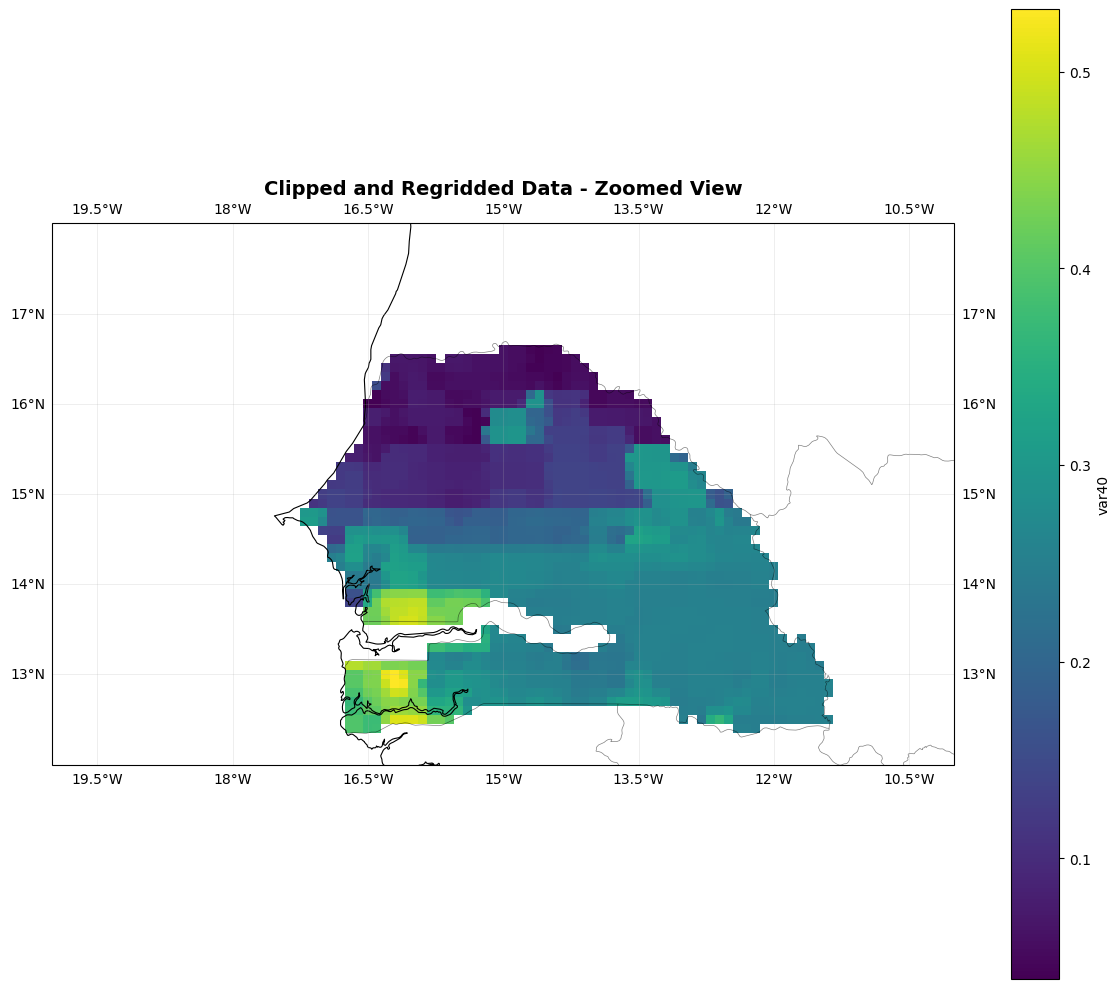

✓ Zoomed plot created!
Data shape: (1, 1801, 3600)
Bounds: lat=[-90.00, 90.00], lon=[-180.00, 179.90]


In [30]:
# Zoom in to the clipped area
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})

clipped['var40'].isel(time=0).plot(ax=ax, transform=ccrs.PlateCarree(), 
                                    cmap='viridis', cbar_kwargs={'label': 'var40'})

# Add coastlines and grid
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5)
ax.add_feature(cfeature.LAKES, alpha=0.3)

# Set the extent to the region
ax.set_xlim([-20, -10])
ax.set_ylim([12, 18])

ax.gridlines(draw_labels=True, alpha=0.3, linewidth=0.5)
ax.set_title('Clipped and Regridded Data - Zoomed View', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Zoomed plot created!")
print(f"Data shape: {clipped['var40'].shape}")
print(f"Bounds: lat=[{clipped.lat.min().values:.2f}, {clipped.lat.max().values:.2f}], lon=[{clipped.lon.min().values:.2f}, {clipped.lon.max().values:.2f}]")

In [2]:
#!pip install vizarr